# Tidal stripping: where and when stars actually escape

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/05-tidal-stripping.ipynb)

The [tidal stream notebook](04-tidal-stream.ipynb) showed *that* a cluster loses
mass in bursts at pericentre. This one asks the more specific question: through
**which part of the cluster** does a star leave, at **what energy**, and **when**?

The answer is the Roche picture. In a frame co-rotating with the cluster's
orbit, the combined host-plus-cluster-plus-centrifugal potential has two saddle
points — the Lagrange points $L_1$ and $L_2$ — sitting on the line joining the
cluster to the Galactic centre. Stars do not evaporate isotropically; they leak
out through those two openings, which is precisely why tidal debris forms two
narrow tails instead of a shell.

We will:

- build the **Roche effective potential** from the host potential and the
  cluster's own mass, and locate $L_1$/$L_2$ numerically,
- check the Lagrange points against the analytic **tidal radius**,
- show **where** on the cluster stars are when they unbind,
- show **when**, and how the stripping rate tracks the bound mass,
- **animate** all of it, with the escaping stars appearing in the
  $\Delta E$–$\Delta L_z$ plane as they go,
- and finish with the **tidal tensor**, which is what you use when the orbit is
  eccentric and the Roche picture stops being valid.

**Runtime.** About one minute for the simulation.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from galpy.potential import (
    MWPotential2014,
    evaluatePotentials,
    evaluateR2derivs,
    evaluateRforces,
    mass,
)
from galpy.util.conversion import mass_in_msol
from scipy.signal import argrelextrema

import tambora
from tambora.dynamics.hooks import BoundednessHook
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.tools.util.units import G_KPC_KMS, KMS_TO_KPCGYR

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(5)
RO, VO = 8.0, 220.0

tambora 0.1.0a1


## 1. Why a circular orbit here

The co-rotating frame is only an *inertial-plus-centrifugal* frame if the
cluster's orbit is circular. On a circular orbit the centrifugal force exactly
balances the host's gravity at the cluster's radius, the effective potential has
a genuine stationary point there, and $L_1$/$L_2$ exist as saddles.

On an eccentric orbit that balance fails. For the run in
[notebook 04](04-tidal-stream.ipynb) — pericentre 5.5 kpc, apocentre 12 kpc —
gravity and the centrifugal term differ by about 15% at any instant, so the
effective potential is dominated by a linear gradient and has no saddle points
at all. We come back to that case in
[section 7](#eccentric-orbits-and-the-tidal-tensor).

So: circular orbit, clean Roche geometry.

In [3]:
R0 = 12.0  # kpc
v_circ = np.sqrt(
    -evaluateRforces(MWPotential2014, R0 / RO, 0.0, use_physical=False)
    * VO**2
    / RO
    * R0
)
Omega = v_circ / R0  # km/s/kpc
print(f"circular speed at {R0} kpc : {v_circ:.2f} km/s")
print(f"angular speed             : {Omega:.3f} km/s/kpc")
print(f"orbital period            : {2 * np.pi / (Omega * KMS_TO_KPCGYR):.3f} Gyr")

circular speed at 12.0 kpc : 209.92 km/s
angular speed             : 17.494 km/s/kpc
orbital period            : 0.351 Gyr


## 2. Set up and run

We pick the cluster's scale radius so it comfortably underfills its Roche lobe
at the start and then bleeds mass steadily.

In [4]:
M_GC, B_GC, N, EPS = 3e4, 0.020, 4000, 0.004

pos, vel, mass_arr = mkPlummer_galpy(
    m=M_GC, b=B_GC, n=N, center_pos=[R0, 0.0, 0.0], center_vel=[0.0, v_circ, 0.0]
)

sim = Sim()
sim.add_particles("gc", pos, vel, mass_arr)
sim.add_external_pot(MWPotential2014)

# capture_transitions records the phase-space coordinates of every star at the
# moment it is first seen to be unbound -- that is the whole point of this notebook.
bh = BoundednessHook(
    "gc", eps=EPS, track=("com", "com_vel"), capture_transitions=("pos", "vel")
)
sim.add_hook(bh)

t0 = time.time()
sim.run(t_end=1.0, dt=2e-4, dt_out=2e-3, eps=EPS, progress=False)
print(f"runtime {time.time() - t0:.0f} s")
print(f"bound fraction  {bh.fraction()[-1]:.3f}")
print(f"|dE/E0|         {sim.monitor.drift['energy'][-1]:.2e}")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(



runtime 31 s
bound fraction  0.585
|dE/E0|         1.37e-08


## 3. The Roche effective potential

In a frame rotating at the cluster's orbital angular velocity $\boldsymbol\Omega$,
a star of unit mass feels

$$
\Phi_{\rm eff}(\mathbf{x})
  = \underbrace{\Phi_{\rm host}(\mathbf{x})}_{\text{Galaxy}}
  + \underbrace{\Phi_{\rm cl}(\mathbf{x})}_{\text{cluster}}
  - \underbrace{\tfrac{1}{2}\,\lvert\boldsymbol\Omega \times \mathbf{x}\rvert^{2}}_{\text{centrifugal}} .
$$

The conserved quantity in this frame is the Jacobi energy
$E_J = \tfrac12 v^2 + \Phi_{\rm eff}$, and the critical surface through
$L_1$/$L_2$ is the boundary a star must cross to leave.

We build a local right-handed frame at the cluster: $\hat{e}_x$ points away
from the Galactic centre, $\hat{e}_y$ along the direction of motion, and
$\hat{e}_z$ along the orbital angular momentum.

In [5]:
def cluster_frame(com, com_vel):
    """Right-handed frame at the cluster: (radially out, along motion, orbit normal)."""
    Om_vec = np.cross(com, com_vel) / np.dot(com, com)  # km/s/kpc
    Om = np.linalg.norm(Om_vec)
    ex = com / np.linalg.norm(com)
    ez = Om_vec / Om
    ey = np.cross(ez, ex)
    return np.array([ex, ey, ez]), Om


def effective_potential(GX, GY, com, basis, Om, m_bound, b_eff):
    """Roche effective potential on a grid in the cluster's orbital plane.

    Returns (km/s)^2. GX, GY are offsets from the cluster centre in kpc along
    the first two basis vectors.
    """
    ex, ey, ez = basis
    P = com[None, None, :] + GX[..., None] * ex + GY[..., None] * ey
    Pf = P.reshape(-1, 3)

    phi = (
        evaluatePotentials(
            MWPotential2014,
            np.hypot(Pf[:, 0], Pf[:, 1]) / RO,
            Pf[:, 2] / RO,
            use_physical=False,
        )
        * VO**2
    )
    d = np.linalg.norm(Pf - com, axis=1)
    phi = phi - G_KPC_KMS * m_bound / np.sqrt(d**2 + b_eff**2)  # cluster, Plummer
    phi = phi - 0.5 * Om**2 * np.linalg.norm(np.cross(Pf, ez), axis=1) ** 2
    return phi.reshape(GX.shape)


def lagrange_points(g, prof):
    """Locate L1/L2 as the local maxima of the effective potential along y=0."""
    idx = argrelextrema(prof, np.greater)[0]
    return g[idx], prof[idx]

The cluster's own contribution is modelled as a Plummer sphere with the
*current* bound mass and a scale radius inferred from the bound half-mass
radius ($r_{1/2} = 1.305\,b$ for a Plummer profile). Both shrink as the cluster
is stripped, so the Roche lobe shrinks with it.

In [6]:
def roche_state(snap):
    """Everything needed to draw the Roche picture at snapshot index `snap`."""
    p, v = sim.gc.pos(t=snap), sim.gc.vel(t=snap)
    bnd = bh.mask_at(sim.times[snap])
    com, com_vel = p[bnd].mean(0), v[bnd].mean(0)
    basis, Om = cluster_frame(com, com_vel)
    m_bound = sim.gc.mass[bnd].sum()
    b_eff = np.median(np.linalg.norm(p[bnd] - com, axis=1)) / 1.305
    return p, v, bnd, com, basis, Om, m_bound, b_eff


SNAP = len(sim.times) // 2
p, v, bnd, com, basis, Om, m_bound, b_eff = roche_state(SNAP)

Rmag = np.linalg.norm(com)
M_enc = mass(MWPotential2014, Rmag / RO) * mass_in_msol(VO, RO)
r_t_simple = Rmag * (m_bound / (3 * M_enc)) ** (1 / 3)

print(f"t = {sim.times[SNAP]:.2f} Gyr")
print(f"bound mass      {m_bound:.3e} Msun")
print(f"b_eff           {b_eff * 1000:.1f} pc")
print(f"r_t (point-mass host) {r_t_simple * 1000:.1f} pc")

t = 0.50 Gyr
bound mass      1.989e+04 Msun
b_eff           15.6 pc
r_t (point-mass host) 46.6 pc


### Locating the Lagrange points

In [7]:
L_BOX = 4 * r_t_simple
n = 401
g = np.linspace(-L_BOX, L_BOX, n)
GX, GY = np.meshgrid(g, g)
PE = effective_potential(GX, GY, com, basis, Om, m_bound, b_eff)

xL, phiL = lagrange_points(g, PE[n // 2, :])
print(f"L1/L2 found at x = {np.round(xL * 1000, 1)} pc")
print(f"analytic r_t     = {r_t_simple * 1000:.1f} pc")
print(f"agreement        = {abs(abs(xL).mean() - r_t_simple) / r_t_simple * 100:.1f}%")

L1/L2 found at x = [-47.5  47.5] pc
analytic r_t     = 46.6 pc
agreement        = 2.0%


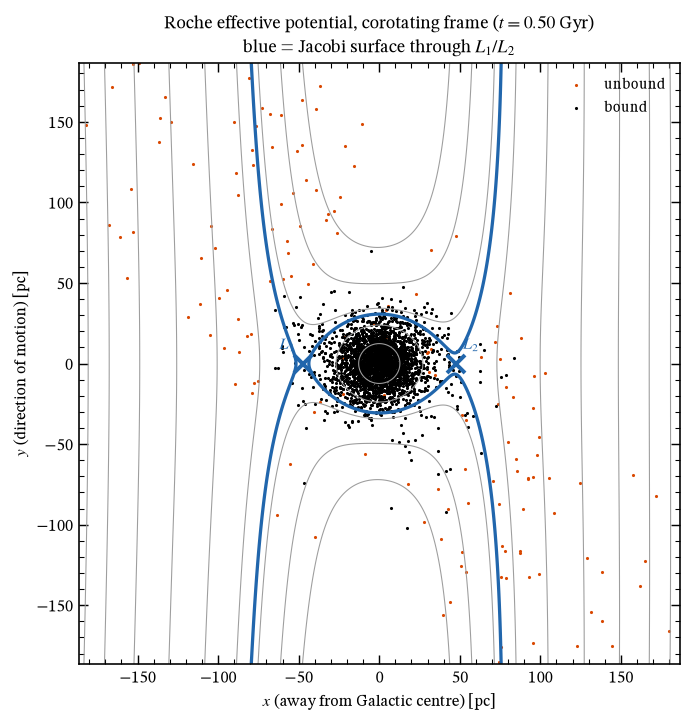

In [8]:
loc = (p - com) @ basis[:2].T

fig, ax = plt.subplots(figsize=(6.6, 6.0))
levels = np.sort(
    np.concatenate([np.percentile(PE, [3, 10, 20, 32, 45, 58, 70, 80, 88]), [phiL.mean()]])
)
ax.contour(GX * 1000, GY * 1000, PE, levels=levels, colors="0.62",
           linewidths=0.6, linestyles="solid")
ax.contour(GX * 1000, GY * 1000, PE, levels=[phiL.mean()], colors="#2166ac",
           linewidths=1.8, linestyles="solid")
ax.scatter(loc[~bnd, 0] * 1000, loc[~bnd, 1] * 1000, s=3, lw=0, c="#d94801",
           label="unbound")
ax.scatter(loc[bnd, 0] * 1000, loc[bnd, 1] * 1000, s=3, lw=0, c="k", label="bound")
for x in xL:
    ax.plot(x * 1000, 0, marker="x", c="#2166ac", ms=10, mew=2.2, zorder=6)
ax.annotate("$L_1$", (xL.min() * 1000, 0), textcoords="offset points",
            xytext=(-4, 8), color="#2166ac", ha="right")
ax.annotate("$L_2$", (xL.max() * 1000, 0), textcoords="offset points",
            xytext=(4, 8), color="#2166ac")
ax.set_xlim(-L_BOX * 1000, L_BOX * 1000)
ax.set_ylim(-L_BOX * 1000, L_BOX * 1000)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$ (away from Galactic centre) [pc]")
ax.set_ylabel(r"$y$ (direction of motion) [pc]")
ax.set_title(
    f"Roche effective potential, corotating frame ($t={sim.times[SNAP]:.2f}$ Gyr)\n"
    "blue = Jacobi surface through $L_1/L_2$"
)
ax.legend(loc="upper right")
plt.show()

That is the whole mechanism in one figure. The bound cluster (black) sits inside
the critical Jacobi surface; the unbound stars (orange) are outside it, and they
are not scattered randomly — they stream out through the two openings at $L_1$
and $L_2$ and then shear into the leading and trailing tails.

## 4. Where stars are when they unbind

`capture_transitions=("pos", "vel")` stored each star's phase-space coordinates
at the fire that first saw it unbind. Transforming those into the co-rotating
frame *at that time* tells us where the escape hatch is.

> **Units.** Captured velocities are in tambora's internal kpc/Gyr; captured
> positions are in kpc, the same in both systems. See
> [Units](../guide/units.md).

> **Rebinding is real.** A star sitting near the Jacobi surface can cross it
> several times before leaving for good — one star in this run flips 47 times.
> `BoundednessHook` records every crossing, which is what you want, but it means
> the raw event count is not the number of escapes. `release_time()` already
> returns the *most recent* unbinding per star; below we go one step further and
> keep only stars that are still unbound at the end.

In [9]:
events = bh.transitions("unbound")
bt = np.asarray(bh.t)
com_hist = np.asarray(bh.com)
com_vel_hist = np.asarray(bh.com_vel) / KMS_TO_KPCGYR  # internal -> km/s

n_unbind = len(events)
n_rebind = len(bh.transitions("bound"))
n_net = (~bh.mask_at(bh.t[-1])).sum()
print(f"{n_unbind} unbinding events, {n_rebind} rebinding events, "
      f"{n_net} net unbound")

# Stars near the Roche boundary cross it repeatedly, so the raw event count far
# exceeds the number of escapes. Keep each star's LAST unbinding, and only for
# stars that are still unbound at the end -- that is the escape that stuck.
final_unbound = ~bh.mask_at(bh.t[-1])
last_escape = {}
for idx, te, direction, xyz, uvw in events:
    if final_unbound[idx]:
        last_escape[idx] = (te, xyz)
print(f"{len(last_escape)} definitive escapes")

rel_xy = np.empty((len(last_escape), 2))
rel_t = np.empty(len(last_escape))
for i, (idx, (te, xyz)) in enumerate(last_escape.items()):
    j = int(np.argmin(np.abs(bt - te)))
    basis_j, _ = cluster_frame(com_hist[j], com_vel_hist[j])
    rel_xy[i] = (xyz - com_hist[j]) @ basis_j[:2].T
    rel_t[i] = te

4931 unbinding events, 3276 rebinding events, 1662 net unbound
1660 definitive escapes


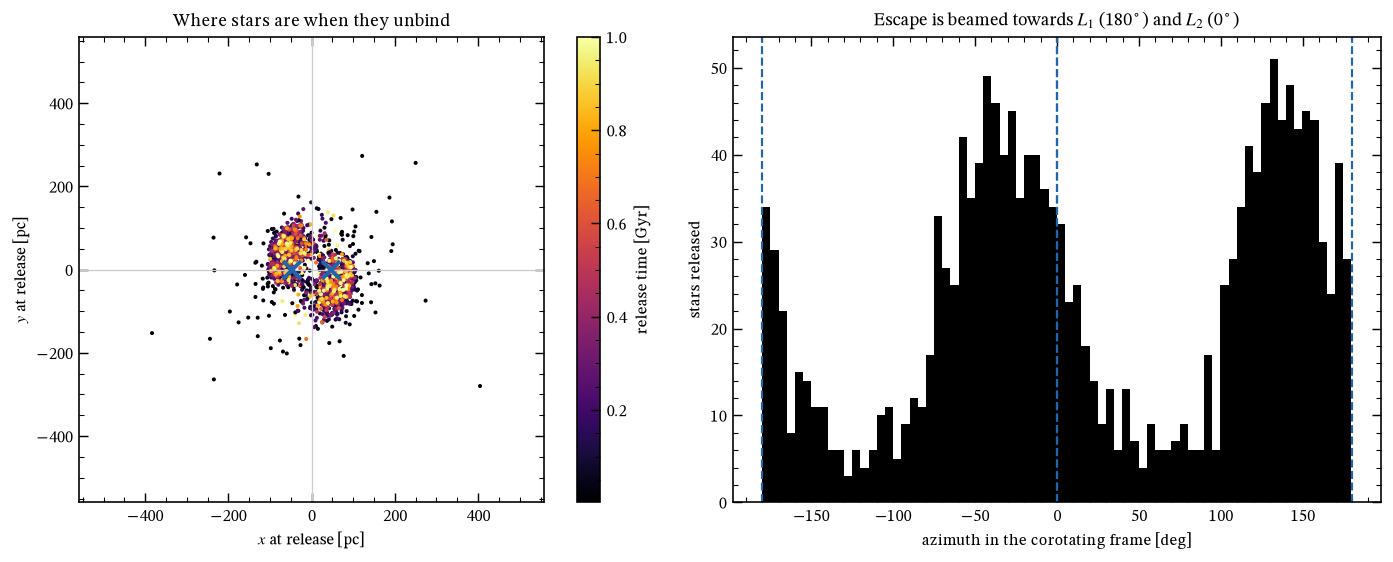

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.4))

a = ax[0]
sc = a.scatter(rel_xy[:, 0] * 1000, rel_xy[:, 1] * 1000, c=rel_t, s=5, lw=0,
               cmap="inferno", rasterized=True)
for x in xL:
    a.plot(x * 1000, 0, marker="x", c="#2166ac", ms=10, mew=2.2, zorder=6)
a.axvline(0, c="0.8", lw=0.7)
a.axhline(0, c="0.8", lw=0.7)
a.set_xlim(-3 * L_BOX * 1000, 3 * L_BOX * 1000)
a.set_ylim(-3 * L_BOX * 1000, 3 * L_BOX * 1000)
a.set_aspect("equal")
a.set_xlabel("$x$ at release [pc]")
a.set_ylabel("$y$ at release [pc]")
a.set_title("Where stars are when they unbind")
plt.colorbar(sc, ax=a, label="release time [Gyr]")

a = ax[1]
theta = np.degrees(np.arctan2(rel_xy[:, 1], rel_xy[:, 0]))
a.hist(theta, bins=72, color="k")
for x, lab in zip(xL, ("$L_1$", "$L_2$")):
    a.axvline(0 if x > 0 else 180, c="#2166ac", lw=1.2, ls="--")
    a.axvline(0 if x > 0 else -180, c="#2166ac", lw=1.2, ls="--")
a.set_xlabel(r"azimuth in the corotating frame [deg]")
a.set_ylabel("stars released")
a.set_title(r"Escape is beamed towards $L_1$ (180$^\circ$) and $L_2$ (0$^\circ$)")
fig.tight_layout()
plt.show()

The histogram is the quantitative version of the picture: releases pile up at
$0^\circ$ and $\pm180^\circ$, the directions of $L_2$ and $L_1$, and are
suppressed perpendicular to the star–Galaxy line.

## 5. When stars unbind

On a circular orbit there is no pericentre to modulate the stripping, so instead
of bursts we get a smooth decline — and the *rate* is what carries the
information.

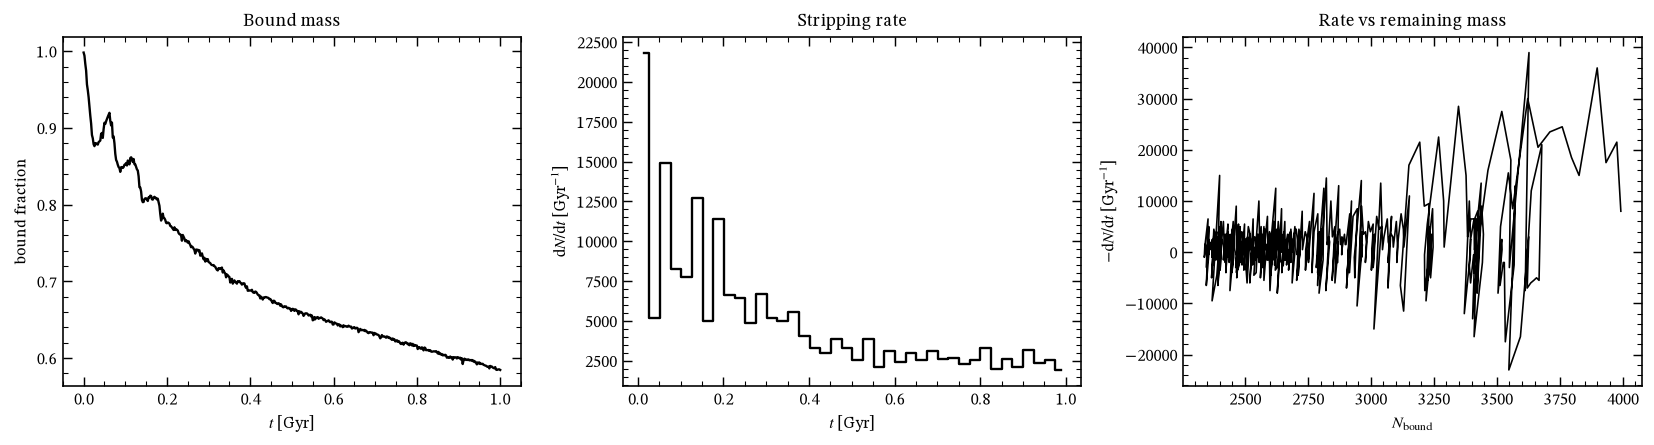

initially bound : 3993
finally bound   : 2338
mass lost       : 41.5%


In [11]:
frac = bh.fraction()
t_rel = bh.transition_times("unbound")

fig, ax = plt.subplots(1, 3, figsize=(12.8, 3.5))

ax[0].plot(bh.t, frac, c="k")
ax[0].set_xlabel("$t$ [Gyr]")
ax[0].set_ylabel("bound fraction")
ax[0].set_title("Bound mass")

counts, edges = np.histogram(t_rel, bins=40)
ctr = 0.5 * (edges[1:] + edges[:-1])
ax[1].step(ctr, counts / np.diff(edges), where="mid", c="k")
ax[1].set_xlabel("$t$ [Gyr]")
ax[1].set_ylabel(r"$\mathrm{d}N/\mathrm{d}t$ [Gyr$^{-1}$]")
ax[1].set_title("Stripping rate")

n_bound = bh.n_bound()
ax[2].plot(n_bound[:-1], -np.diff(n_bound) / np.diff(bh.t), c="k", lw=0.9)
ax[2].set_xlabel("$N_{\\rm bound}$")
ax[2].set_ylabel(r"$-\mathrm{d}N/\mathrm{d}t$ [Gyr$^{-1}$]")
ax[2].set_title("Rate vs remaining mass")
fig.tight_layout()
plt.show()

print(f"initially bound : {bh.initial_mask.sum()}")
print(f"finally bound   : {n_bound[-1]}")
print(f"mass lost       : {(1 - frac[-1]) * 100:.1f}%")

## 6. Animate the escape

Two panels, in sync. On the left, the cluster in its co-rotating frame with the
Roche contours and Lagrange points redrawn as the lobe shrinks. On the right,
every star adds a point the moment it unbinds, coloured by when that happened.

For the right-hand axis we plot the **Jacobi energy** offset rather than the
plain energy. On a circular orbit $\Delta E$ and $\Delta L_z$ are locked
together by $\Delta E = \Omega\,\Delta L_z$ — they carry the same information,
so a $\Delta E$–$\Delta L_z$ scatter collapses onto a line. The combination that
is *not* degenerate is exactly the one the rotating frame conserves,

$$ E_J = E - \Omega L_z = \tfrac12 v^2 + \Phi_{\rm eff}, $$

and escape is precisely the condition that a star's $E_J$ rises above the value
at $L_1/L_2$. Bound stars sit in a tight clump near $\Delta E_J = 0$; escapees
lift off it.

First, the per-snapshot energies and angular momenta. `Lz` is cheap from the
arrays; for the energy we evaluate the host potential vectorised over every
snapshot at once rather than looping, which is far faster than asking for
`sim.energy(t=...)` across all times.

In [12]:
P_all = sim.gc.pos()  # (nsnap, N, 3)  kpc
V_all = sim.gc.vel()  # (nsnap, N, 3)  km/s
m_p = sim.gc.mass

Lz_all = m_p[None, :] * (P_all[..., 0] * V_all[..., 1] - P_all[..., 1] * V_all[..., 0])

flat = P_all.reshape(-1, 3)
phi_ext = (
    evaluatePotentials(
        MWPotential2014,
        np.hypot(flat[:, 0], flat[:, 1]) / RO,
        flat[:, 2] / RO,
        use_physical=False,
    )
    * VO**2
).reshape(P_all.shape[:2])

KE_all = 0.5 * m_p[None, :] * np.sum(V_all**2, axis=-1)
E_all = KE_all + m_p[None, :] * phi_ext  # host-frame orbital energy

# The conserved quantity in the rotating frame is the Jacobi energy,
#     E_J = E - Omega * L_z ,
# and a star escapes when its E_J rises above the value at L1/L2. Include the
# cluster's own potential -- tambora already cached it during the run, so this
# is a lookup, not a recomputation.
phi_self = sim.gc.self_potential() / m_p[None, :]  # specific, (km/s)^2
EJ_all = (KE_all + m_p[None, :] * (phi_ext + phi_self)) / m_p[None, :] - Omega * (
    Lz_all / m_p[None, :]
)
print("E", E_all.shape, "Lz", Lz_all.shape, "E_J", EJ_all.shape)

E (501, 4000) Lz (501, 4000) E_J (501, 4000)


/var/folders/s1/bxkg8f1501g2q16qjhch2_qw0000gn/T/ipykernel_57362/3042811241.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  sc_esc = a1.scatter([], [], s=7, lw=0, cmap="inferno", vmin=0,



animation: 84 frames, 3.0 MB


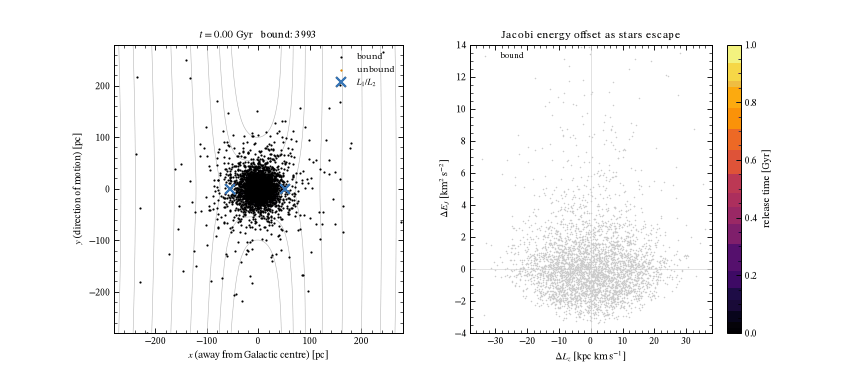

In [13]:
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402
from IPython.display import Image  # noqa: E402

STEP = 6
frames = range(0, len(sim.times), STEP)
masks = np.array([bh.mask_at(t) for t in sim.times])
rel_time = bh.release_time()

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11.0, 4.8))

BOX = 6 * r_t_simple * 1000  # pc
cs_holder = {"c": None}
sc_b = a0.scatter([], [], s=4, lw=0, c="k", label="bound", zorder=4)
sc_u = a0.scatter([], [], s=4, lw=0, c="#d94801", label="unbound", zorder=3)
(lag,) = a0.plot([], [], "x", c="#2166ac", ms=9, mew=2.0, zorder=6, label="$L_1/L_2$")
a0.set_xlim(-BOX, BOX)
a0.set_ylim(-BOX, BOX)
a0.set_aspect("equal")
a0.set_xlabel("$x$ (away from Galactic centre) [pc]")
a0.set_ylabel("$y$ (direction of motion) [pc]")
a0.legend(loc="upper right", fontsize=8)
ttl = a0.set_title("")

# reference values from the first frame, so offsets are measured consistently
b0 = masks[0]
Lz_ref = Lz_all[0, b0].mean() / m_p[0]

LZ_LIM = 38.0
EJ_ref = np.median(EJ_all[0, masks[0]])
a1.set_xlim(-LZ_LIM, LZ_LIM)
a1.set_ylim(-4, 14)
a1.axhline(0, c="0.85", lw=0.7)
a1.axvline(0, c="0.85", lw=0.7)
a1.set_xlabel(r"$\Delta L_z$ [kpc km s$^{-1}$]")
a1.set_ylabel(r"$\Delta E_J$ [km$^2$ s$^{-2}$]")
a1.set_title("Jacobi energy offset as stars escape")
sc_bound = a1.scatter([], [], s=2, lw=0, c="0.8", zorder=2, label="bound")
sc_esc = a1.scatter([], [], s=7, lw=0, cmap="inferno", vmin=0,
                    vmax=float(sim.times[-1]), zorder=3)
a1.legend(loc="upper left", fontsize=7.5)
cb = fig.colorbar(sc_esc, ax=a1, label="release time [Gyr]")


def update(i):
    p_i, v_i = P_all[i], V_all[i]
    bnd_i = masks[i]
    com_i, comv_i = p_i[bnd_i].mean(0), v_i[bnd_i].mean(0)
    basis_i, Om_i = cluster_frame(com_i, comv_i)
    mb_i = m_p[bnd_i].sum()
    beff_i = np.median(np.linalg.norm(p_i[bnd_i] - com_i, axis=1)) / 1.305

    # contours, redrawn each frame as the lobe shrinks
    if cs_holder["c"] is not None:
        cs_holder["c"].remove()
    gg = np.linspace(-BOX / 1000, BOX / 1000, 121)
    GXi, GYi = np.meshgrid(gg, gg)
    PEi = effective_potential(GXi, GYi, com_i, basis_i, Om_i, mb_i, beff_i)
    lv = np.sort(np.percentile(PEi, [5, 15, 28, 42, 56, 70, 82, 91]))
    cs_holder["c"] = a0.contour(GXi * 1000, GYi * 1000, PEi, levels=lv,
                                colors="0.7", linewidths=0.5, linestyles="solid")

    # Lagrange points for THIS frame's lobe
    prof_i = PEi[len(gg) // 2, :]
    xL_i, _ = lagrange_points(gg, prof_i)
    lag.set_data(xL_i * 1000, np.zeros_like(xL_i))

    loc_i = (p_i - com_i) @ basis_i[:2].T * 1000
    sc_b.set_offsets(loc_i[bnd_i])
    sc_u.set_offsets(loc_i[~bnd_i])
    ttl.set_text(f"$t = {sim.times[i]:.2f}$ Gyr   bound: {bnd_i.sum()}")

    dEJ = EJ_all[i] - EJ_ref
    dLz = Lz_all[i] / m_p - Lz_ref
    sc_bound.set_offsets(np.c_[dLz[bnd_i], dEJ[bnd_i]])
    esc = (~bnd_i) & np.isfinite(rel_time) & (rel_time <= sim.times[i])
    sc_esc.set_offsets(np.c_[dLz[esc], dEJ[esc]])
    sc_esc.set_array(rel_time[esc])
    return sc_b, sc_u, sc_bound, sc_esc, ttl, lag


anim = FuncAnimation(fig, update, frames=frames, blit=False)
anim.save("tidal_stripping.gif", writer=PillowWriter(fps=7), dpi=78)
plt.close(fig)

# Redrawing contours every frame defeats GIF inter-frame compression, so quantise
# the palette afterwards -- this run goes from ~6.6 MB to well under 2 MB with no
# visible difference.
from PIL import Image as PILImage, ImageSequence  # noqa: E402

_src = PILImage.open("tidal_stripping.gif")
_frames = [f.copy().convert("RGB").quantize(colors=96, method=PILImage.MEDIANCUT)
           for f in ImageSequence.Iterator(_src)]
_frames[0].save("tidal_stripping.gif", save_all=True, append_images=_frames[1:],
                duration=int(1000 / 7), loop=0, optimize=True)
print(f"animation: {len(_frames)} frames, "
      f"{__import__('os').path.getsize('tidal_stripping.gif') / 1e6:.1f} MB")

Image(filename="tidal_stripping.gif")

Watch the two panels together. Stars leave the black clump on the left through
the two $L$-point openings, and appear on the right lifted above
$\Delta E_J = 0$ — they have gained Jacobi energy, which is what "unbound in the
rotating frame" means.

The sign of $\Delta L_z$ then decides which tail they join: stars that leave
through $L_1$ (towards the Galactic centre) lose angular momentum, drop onto a
tighter, shorter-period orbit and run **ahead** of the progenitor; stars leaving
through $L_2$ gain angular momentum and fall **behind**. That is the origin of
the two-tailed morphology, visible here as the two horns spreading left and
right.

(eccentric-orbits-and-the-tidal-tensor)=
## 7. Eccentric orbits, and the tidal tensor

Everything above needed a circular orbit. Real satellites are eccentric, and
then the co-rotating frame stops being useful: the centrifugal term no longer
balances the host's gravity, so $\Phi_{\rm eff}$ is dominated by a linear
gradient and there are no Lagrange points to find.

You can check this directly.

In [14]:
for label, R, v_t in [("circular  ", R0, v_circ), ("eccentric ", 8.41, 201.2)]:
    g_grav = -evaluateRforces(MWPotential2014, R / RO, 0.0, use_physical=False) * VO**2 / RO
    Om_here = v_t / R
    print(
        f"{label} R={R:5.2f} kpc:  g_grav={g_grav:7.1f}   "
        f"Omega^2 R={Om_here**2 * R:7.1f}   imbalance={100 * abs(g_grav - Om_here**2 * R) / g_grav:4.1f}%"
    )

circular   R=12.00 kpc:  g_grav= 3672.3   Omega^2 R= 3672.3   imbalance= 0.0%
eccentric  R= 8.41 kpc:  g_grav= 5695.6   Omega^2 R= 4813.5   imbalance=15.5%


The standard replacement is to keep only the **tidal** part of the external
field: expand the host potential to second order about the cluster centre and
throw away the constant and linear terms, which merely accelerate the cluster
as a whole. What remains is the tidal tensor

$$ T_{ij} = -\frac{\partial^{2}\Phi_{\rm host}}{\partial x_i \partial x_j} $$

evaluated at the cluster's position. tambora exposes this as
{class}`~tambora.dynamics.TidalTensorGalpyForce`.

In [15]:
from tambora.dynamics import ExternalGalpyPotential, TidalTensorGalpyForce  # noqa: E402

centre = np.array([R0, 0.0, 0.0])
tt = TidalTensorGalpyForce(MWPotential2014, center=centre)

T = tt.tidal_tensor(np.array([centre]))
eigval, eigvec = np.linalg.eigh(T)

print("tidal tensor at R = 12 kpc  [1/Gyr^2]")
print(np.round(T, 1))
print("\neigenvalues:", np.round(eigval, 1))
print("stretching direction:", np.round(eigvec[:, np.argmax(eigval)], 3))

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(

tidal tensor at R = 12 kpc  [1/Gyr^2]
[[  398.1    -0.     -0. ]
 [   -0.   -320.1    -0. ]
 [   -0.     -0.  -2027.3]]

eigenvalues: [-2027.3  -320.1   398.1]
stretching direction: [1. 0. 0.]


The signs tell the story: one positive eigenvalue along the Galactocentric
radial direction (**stretching** — this is what pulls the tails out), and two
negative ones (**compressing**) along the direction of motion and, much more
strongly, perpendicular to the disk.

Adding the centrifugal contribution $\Omega^2$ to the radial eigenvalue recovers
the Jacobi tidal radius, and it is a *better* estimate than the usual
point-mass formula because it uses the real curvature of the host potential:

In [16]:
d2Phi = evaluateR2derivs(MWPotential2014, R0 / RO, 0.0, use_physical=False) * VO**2 / RO**2
lam_eff = Omega**2 - d2Phi  # (km/s/kpc)^2

r_t_tensor = (G_KPC_KMS * M_GC / lam_eff) ** (1 / 3)
M_enc0 = mass(MWPotential2014, R0 / RO) * mass_in_msol(VO, RO)
r_t_point = R0 * (M_GC / (3 * M_enc0)) ** (1 / 3)

print(f"r_t from the tidal tensor : {r_t_tensor * 1000:.1f} pc")
print(f"r_t from the point-mass formula : {r_t_point * 1000:.1f} pc")
print(f"difference : {100 * (r_t_tensor - r_t_point) / r_t_point:+.1f}%")

r_t from the tidal tensor : 57.3 pc
r_t from the point-mass formula : 53.4 pc
difference : +7.2%


### What the tidal-tensor force is for

`TidalTensorGalpyForce` is a *force*, not just a diagnostic — you can integrate
with it in place of the full external potential:

```python
sim.add_external_force(TidalTensorGalpyForce(MWPotential2014, center=orbit_position))
```

Doing so is useful in three situations:

1. **Isolating the tidal response.** The full potential accelerates the cluster
   bodily *and* strains it. The tensor force keeps only the strain, so the
   cluster stays put in the box and you see the tidal deformation on its own,
   uncontaminated by bulk motion.
2. **Attributing cause.** Comparing a run with the full potential against one
   with only the linear tide tells you how much of the mass loss is the smooth
   tide and how much comes from higher-order terms — disk crossings, a bar, a
   rapidly changing tidal field near pericentre.
3. **Cheapness.** Evaluating one $3\times3$ tensor per step and applying it as a
   matrix multiply is far cheaper than evaluating a composite galpy potential at
   every particle.

The cost is that it is a *local* approximation. It is accurate while the cluster
is small compared with the scale over which the tidal field varies — true for a
bound cluster, and increasingly false for the extended tails, which is why you
would not use it to evolve a long stream.

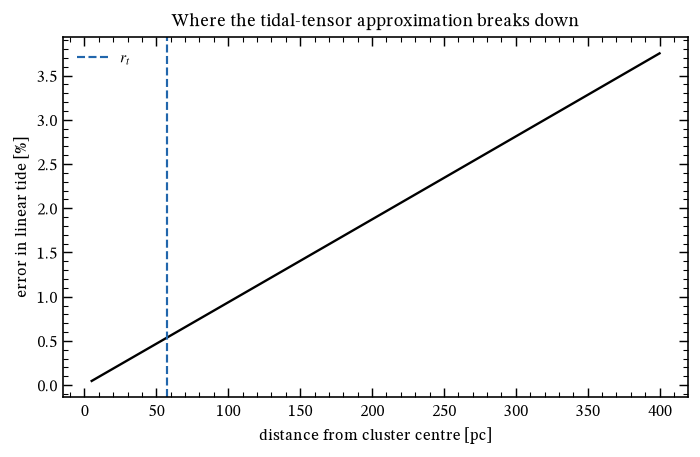

In [17]:
# How good is the linear approximation across the cluster?
offsets = np.array([[r, 0.0, 0.0] for r in np.linspace(0.005, 0.4, 40)])
pts = centre + offsets

a_full = ExternalGalpyPotential(MWPotential2014).acc(pts, 0.0)
a_cent = ExternalGalpyPotential(MWPotential2014).acc(centre[None, :], 0.0)
a_tidal_true = a_full - a_cent  # exact tidal part
a_tidal_lin = tt.acc(pts, 0.0)  # linear approximation

r = offsets[:, 0]
err = np.abs(a_tidal_lin[:, 0] - a_tidal_true[:, 0]) / np.abs(a_tidal_true[:, 0])

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(r * 1000, 100 * err, c="k")
ax.axvline(r_t_tensor * 1000, c="#2166ac", ls="--", lw=1.2, label="$r_t$")
ax.set_xlabel("distance from cluster centre [pc]")
ax.set_ylabel("error in linear tide [%]")
ax.set_title("Where the tidal-tensor approximation breaks down")
ax.legend()
plt.show()

Inside the tidal radius the linear tide is good to well under a percent; by a
few hundred parsec — out in the tails — it is degrading fast. That is exactly the
regime boundary: use the tensor for the **progenitor**, use the full potential
for the **stream**.

## Where to go next

- [Stream tracks and observables](06-stream-track.ipynb) — turn the debris into
  something you could compare with Gaia.
- [Subhalo impacts and stream gaps](07-stream-gaps.ipynb) — perturb the stream
  and measure the response against theory.
- [Hooks](../guide/hooks.md) — writing your own, and what `BoundednessHook`
  records.

Things to try:

- Re-run at a **smaller** `B_GC`. The Roche lobe is unchanged but the cluster
  underfills it, and the stripping rate collapses.
- Move the orbit to `R0 = 6.0`. The tidal field is much stronger, so the lobe
  shrinks and the cluster dissolves within a few hundred Myr.
- Swap `add_external_pot(MWPotential2014)` for
  `add_external_force(TidalTensorGalpyForce(...))` and compare the mass-loss
  curves.